# Quine — Benchmark Results Visualiser
Reads all JSON results from `results/` and renders hallucination analysis.

In [1]:
import os
import json
import glob
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

BG     = '#0d1117'
BG2    = '#161b22'
BORDER = '#30363d'
TEXT   = '#e6edf3'
MUTED  = '#8b949e'
RED    = '#f85149'
BLUE   = '#388bfd'
GREEN  = '#3fb950'
YELLOW = '#d29922'
PURPLE = '#bc8cff'
PALETTE = [RED, BLUE, GREEN, YELLOW, PURPLE, '#ff7b72', '#79c0ff']

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor':   BG2,
    'axes.edgecolor':   BORDER,
    'axes.labelcolor':  TEXT,
    'xtick.color':      TEXT,
    'ytick.color':      TEXT,
    'text.color':       TEXT,
    'legend.facecolor': BG2,
    'legend.edgecolor': BORDER,
})
print('Ready.')

Ready.


In [2]:
def load_flat_results():
    """Load single-run benchmark results (results/{provider}/{model}/*.json)"""
    best = {}  # model -> latest summary
    for path in glob.glob('results/*/*/*.json'):
        if 'curve' in path:
            continue
        with open(path) as f:
            d = json.load(f)
        model = d.get('model', 'unknown')
        if model not in best or d['timestamp'] > best[model]['timestamp']:
            best[model] = d
    return list(best.values())

def load_curve_results():
    """Load variable curve results (results/curve/{model}/*.json)"""
    model_data = defaultdict(dict)
    for path in glob.glob('results/curve/**/*.json', recursive=True):
        with open(path) as f:
            d = json.load(f)
        model = d.get('model', 'unknown')
        n = d.get('n_vars')
        if n is None:
            continue
        if n not in model_data[model] or d['timestamp'] > model_data[model][n]['timestamp']:
            model_data[model][n] = d
    return model_data

flat    = load_flat_results()
curve   = load_curve_results()
flat.sort(key=lambda x: x['hallucination_rate'])
print(f'Loaded {len(flat)} flat benchmarks, {len(curve)} curve models')
for s in flat:
    print(f"  {s['model']:45s}  {s['hallucination_rate']:.1f}%  ({s['total']} cases)")

Loaded 6 flat benchmarks, 1 curve models
  groq/qwen/qwen3-32b                            20.0%  (10 cases)
  groq/llama-3.3-70b-versatile                   20.0%  (100 cases)
  ollama/gemma3:4b                               36.4%  (11 cases)
  ollama/tinyllama                               50.0%  (4 cases)
  ollama/llama3.2:3b                             50.0%  (20 cases)
  groq/llama-3.1-8b-instant                      50.0%  (10 cases)


## 1 — Overall hallucination rate by model

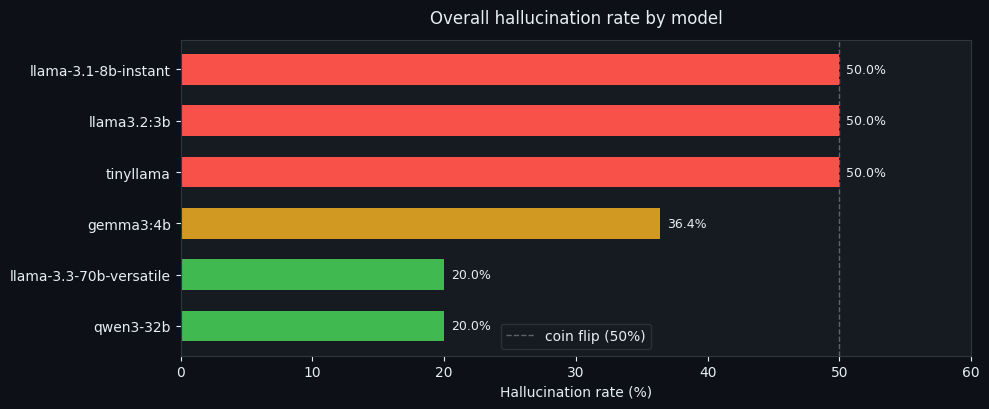

In [3]:
models = [s['model'].split('/')[-1] for s in flat]
rates  = [s['hallucination_rate'] for s in flat]
colors = [RED if r > 40 else YELLOW if r > 20 else GREEN for r in rates]

fig, ax = plt.subplots(figsize=(10, max(4, len(models) * 0.7)))
bars = ax.barh(models, rates, color=colors, height=0.6)
ax.axvline(50, color=MUTED, linewidth=1, linestyle='--', alpha=0.6, label='coin flip (50%)')
ax.set_xlabel('Hallucination rate (%)')
ax.set_title('Overall hallucination rate by model', pad=12)
ax.set_xlim(0, 60)
for bar, rate in zip(bars, rates):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{rate:.1f}%', va='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

## 2 — Error breakdown: missed conflicts vs missed compatibles

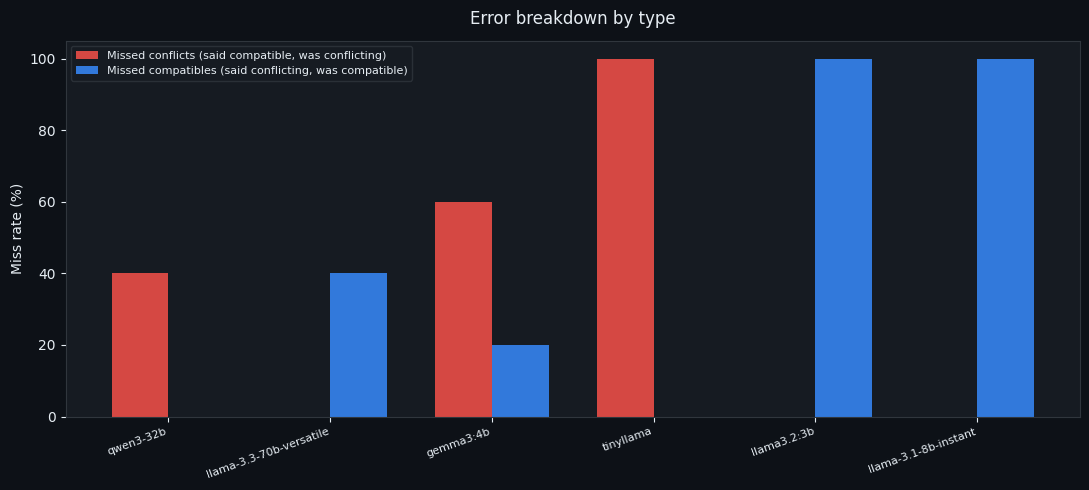

In [4]:
labels   = [s['model'].split('/')[-1] for s in flat]
half     = [s['total'] // 2 for s in flat]
mc_rates = [s['missed_conflicts'] / h * 100 for s, h in zip(flat, half)]
mp_rates = [s['missed_compat']    / h * 100 for s, h in zip(flat, half)]

x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w/2, mc_rates, w, label='Missed conflicts (said compatible, was conflicting)', color=RED,  alpha=0.85)
ax.bar(x + w/2, mp_rates, w, label='Missed compatibles (said conflicting, was compatible)', color=BLUE, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=8)
ax.set_ylabel('Miss rate (%)')
ax.set_title('Error breakdown by type', pad=12)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 3 — Variable curve: hallucination rate vs logical complexity

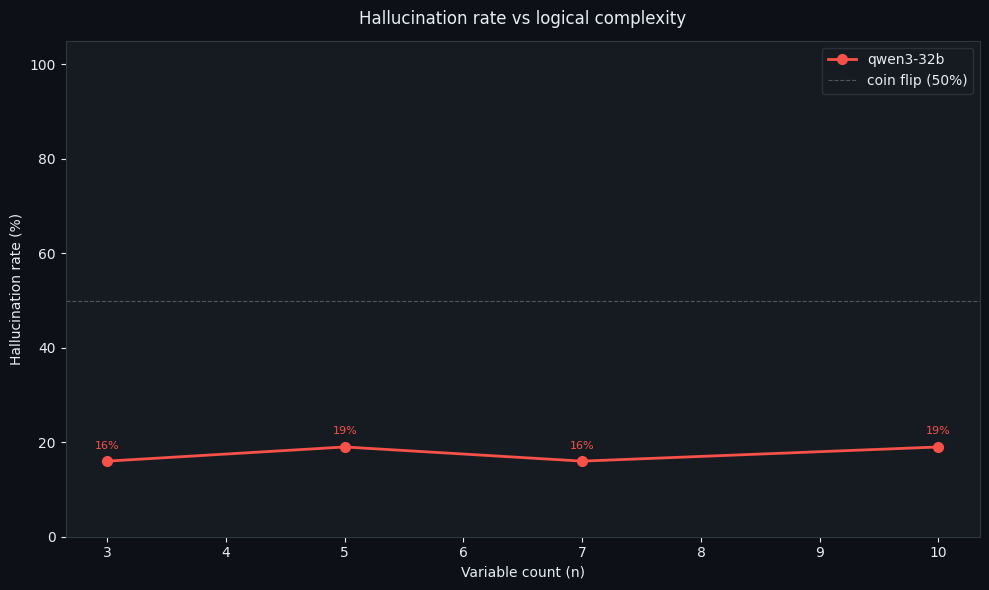

In [5]:
if not curve:
    print('No curve results found. Run curve.py first.')
else:
    fig, ax = plt.subplots(figsize=(10, 6))
    for i, (model, by_vars) in enumerate(sorted(curve.items())):
        xs = sorted(by_vars.keys())
        ys = [by_vars[n]['hallucination_rate'] for n in xs]
        col = PALETTE[i % len(PALETTE)]
        ax.plot(xs, ys, marker='o', linewidth=2, markersize=7, color=col,
                label=model.split('/')[-1])
        for x_, y_ in zip(xs, ys):
            ax.annotate(f'{y_:.0f}%', (x_, y_),
                        textcoords='offset points', xytext=(0, 9),
                        ha='center', fontsize=8, color=col)
    ax.axhline(50, color=MUTED, linewidth=0.8, linestyle='--', alpha=0.5, label='coin flip (50%)')
    ax.set_xlabel('Variable count (n)')
    ax.set_ylabel('Hallucination rate (%)')
    ax.set_title('Hallucination rate vs logical complexity', pad=12)
    ax.set_ylim(0, 105)
    ax.legend()
    plt.tight_layout()
    plt.show()

## 4 — Per-case strip: did the model reason or default?

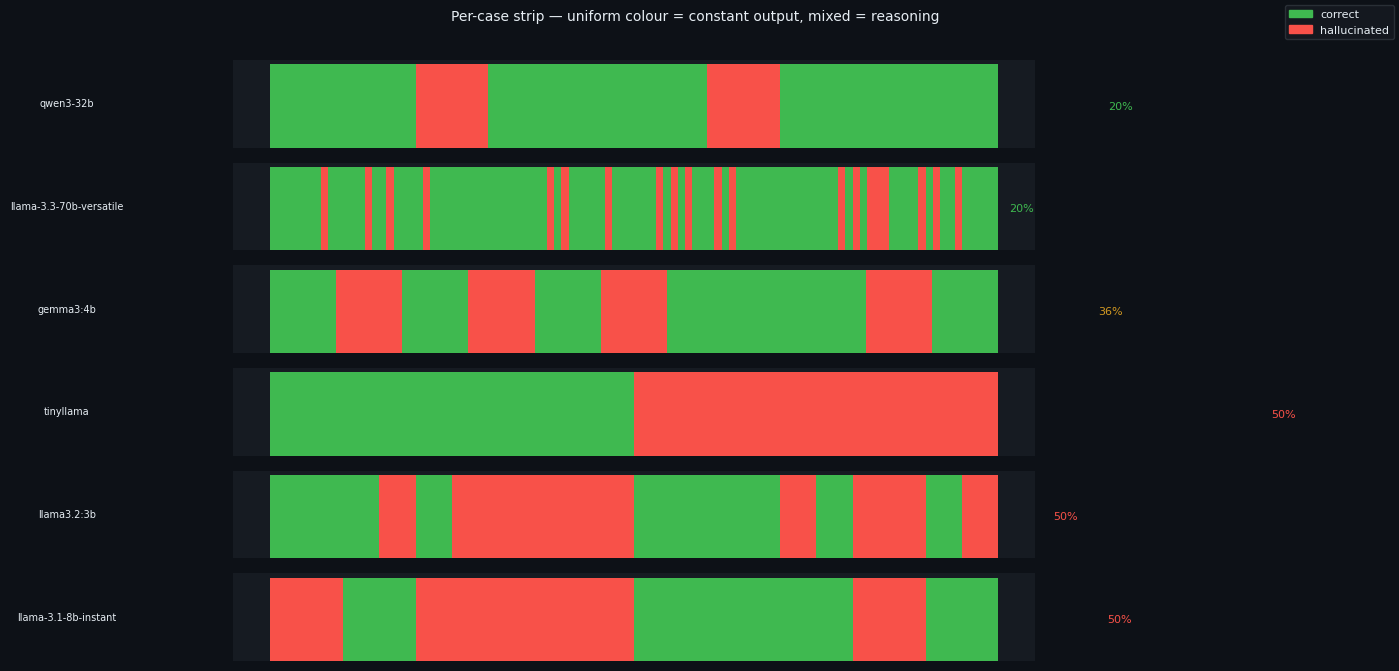

In [6]:
fig, axes = plt.subplots(len(flat), 1, figsize=(14, len(flat) * 1.1))
if len(flat) == 1:
    axes = [axes]

for ax, summary in zip(axes, flat):
    cases = summary.get('results', [])
    if not cases:
        continue
    colors_strip = []
    for r in cases:
        if r['correct']:
            colors_strip.append(GREEN)
        else:
            colors_strip.append(RED)
    ax.bar(range(len(cases)), [1]*len(cases), color=colors_strip, width=1.0)
    ax.set_yticks([])
    ax.set_xticks([])
    rate = summary['hallucination_rate']
    col  = RED if rate > 40 else YELLOW if rate > 20 else GREEN
    ax.set_ylabel(summary['model'].split('/')[-1], fontsize=7, rotation=0,
                  labelpad=120, va='center')
    ax.text(len(cases) + 1, 0.5, f"{rate:.0f}%", va='center', fontsize=8, color=col)
    for spine in ax.spines.values():
        spine.set_visible(False)

green_patch = mpatches.Patch(color=GREEN, label='correct')
red_patch   = mpatches.Patch(color=RED,   label='hallucinated')
fig.legend(handles=[green_patch, red_patch], loc='upper right', fontsize=8)
fig.suptitle('Per-case strip — uniform colour = constant output, mixed = reasoning', 
             fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

## 5 — Summary table

In [7]:
print(f"{'Model':<45} {'Cases':>6} {'Correct':>8} {'Halluc':>8} {'Rate':>7} {'Miss conflict':>14} {'Miss compat':>12}")
print('-' * 105)
for s in flat:
    h = s['total'] // 2
    print(
        f"{s['model']:<45} "
        f"{s['total']:>6} "
        f"{s['correct']:>8} "
        f"{s['hallucinated']:>8} "
        f"{s['hallucination_rate']:>6.1f}% "
        f"{s['missed_conflicts']:>5}/{h}  ({s['missed_conflicts']/h*100:.0f}%)"
        f"{s['missed_compat']:>5}/{h}  ({s['missed_compat']/h*100:.0f}%)"
    )

Model                                          Cases  Correct   Halluc    Rate  Miss conflict  Miss compat
---------------------------------------------------------------------------------------------------------
groq/qwen/qwen3-32b                               10        8        2   20.0%     2/5  (40%)    0/5  (0%)
groq/llama-3.3-70b-versatile                     100       80       20   20.0%     0/50  (0%)   20/50  (40%)
ollama/gemma3:4b                                  11        7        4   36.4%     3/5  (60%)    1/5  (20%)
ollama/tinyllama                                   4        2        2   50.0%     2/2  (100%)    0/2  (0%)
ollama/llama3.2:3b                                20       10       10   50.0%     0/10  (0%)   10/10  (100%)
groq/llama-3.1-8b-instant                         10        5        5   50.0%     0/5  (0%)    5/5  (100%)
